ASTR8004 Assignment 2, Question 3

4.1 Tramlines

In [158]:
#imports for full question 4
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.signal import find_peaks

In [159]:
#Load flat field data

with fits.open('data/flat.fits') as hdul:
    hdul.info()
    flat = hdul[0].data

print("Array shape:", flat.shape)


Filename: data/flat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (385, 4112)   float64   
Array shape: (4112, 385)


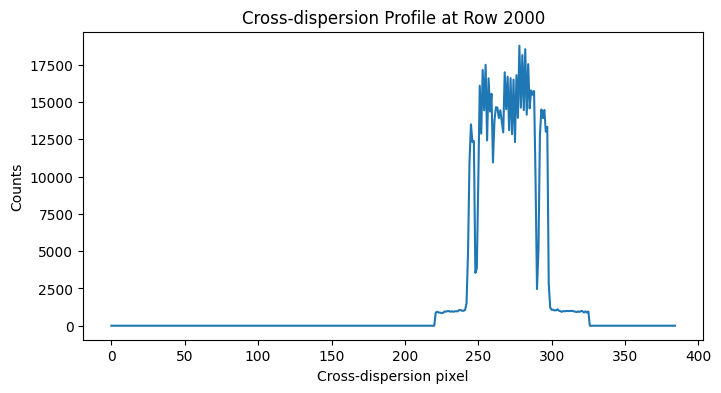

In [160]:
#look at cross dispersion profile

row_index = 2000 #chose a row from the middle

profile = flat[row_index, :]

plt.figure(figsize=(8, 4))
plt.plot(profile)
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Counts')
plt.title(f'Cross-dispersion Profile at Row {row_index}')
plt.savefig("figures/4_1_cross_dispersion_profile.png", dpi=300)    
plt.show()


At row 2000 there are two dips in the corss-dispersion pixel. Now, we do this for all rows, and fit a curve through each dip position to find the tramlines.

To do this, find the minimum of the graph within a specified range. The left dip appears to be around 245, and the right dip at around 290. The search windows will be kept small in order to reduce possible noise from the bright areas. 

In [161]:
n_rows = flat.shape[0]

#empty arrays for tram lines, filled with placeholder values
left_tramline = np.full(n_rows, np.nan) 
right_tramline = np.full(n_rows, np.nan)

half_width = 30   #search 30 pixels on either side of the previous position
max_step = 8       #don't trust a jump of more than 8 pixels between adjacent rows
smooth_width = 5 #smooth the profile slightly to reduce noise before searching
order_threshold = 1500   #pixels below this are background, not the illuminated order

#start using known values from row 2000
start_row = 2000
left_tramline[start_row] = 245
right_tramline[start_row] = 290

def find_dip(profile, prev_pos, half_width, max_step, smooth_width, order_threshold):
    #smooth the profile a little so single noisy pixels don't fake a dip
    kernel = np.ones(smooth_width) / smooth_width
    smoothed = np.convolve(profile, kernel, mode='same')

    #search window centred on the previous row's position, clipped to valid pixels
    low = max(0, int(prev_pos - half_width))
    high = min(len(profile), int(prev_pos + half_width))
    window = smoothed[low:high]

    #only consider pixels that are actually inside the illuminated order
    in_order = window > order_threshold

    if not np.any(in_order):
        #no illuminated pixels found nearby - don't move, just keep the previous position
        return prev_pos

    #among illuminated pixels only, find the darkest one - this is the true dip
    order_indices = np.where(in_order)[0]
    darkest_in_order = order_indices[np.argmin(window[order_indices])]
    candidate = low + darkest_in_order

    #limit how far it can move in one row, to resist single-row noise
    if abs(candidate - prev_pos) > max_step:
        direction = 1 if candidate > prev_pos else -1
        candidate = prev_pos + direction * max_step

    return candidate

#row 2000 to the top of the image
for row in range(start_row + 1,n_rows):
    profile = flat[row, :]
    left_tramline[row] = find_dip(profile, left_tramline[row - 1], half_width, max_step, smooth_width, order_threshold)
    right_tramline[row] = find_dip(profile, right_tramline[row - 1], half_width, max_step, smooth_width, order_threshold)

#row 2000 to the bottom of the image
for row in range(start_row - 1, -1, -1):
    profile = flat[row, :]
    left_tramline[row] = find_dip(profile, left_tramline[row + 1], half_width, max_step, smooth_width, order_threshold)
    right_tramline[row] = find_dip(profile, right_tramline[row + 1], half_width, max_step, smooth_width, order_threshold)

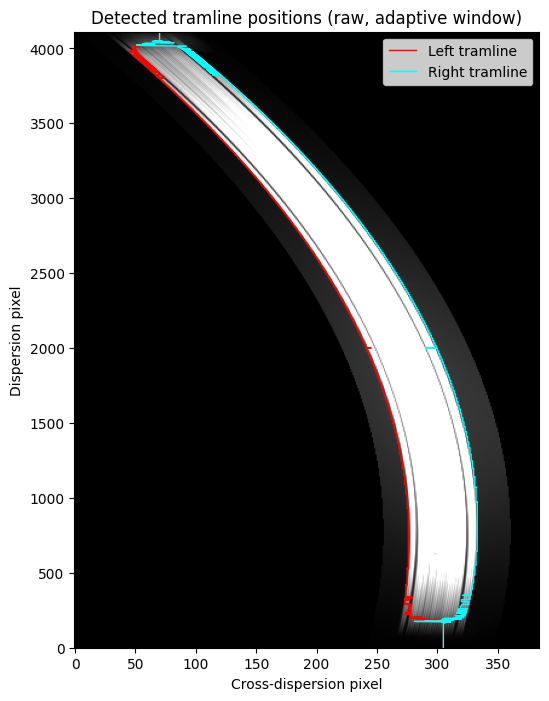

In [162]:
plt.figure(figsize=(6, 8))
plt.imshow(flat, aspect='auto', origin='lower', cmap='gray', vmax=5000)
plt.plot(left_tramline, np.arange(n_rows), color='red', lw=1, label='Left tramline')
plt.plot(right_tramline, np.arange(n_rows), color='cyan', lw=1, label='Right tramline')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.legend()
plt.title('Detected tramline positions (raw, adaptive window)')
plt.savefig("figures/4_1_detected_tramlines.png", dpi=300)
plt.show()

In [163]:
#Fit smooth polynomials to the tram lines

dispersion_pixels = np.arange(n_rows)

#Find order of polynomial that gives a good fit without overfitting
for test_order in [3, 4, 5, 6, 7]:
    coeffs = np.polyfit(dispersion_pixels, left_tramline, deg=test_order)
    fit = np.polyval(coeffs, dispersion_pixels)
    rms = np.sqrt(np.mean((left_tramline - fit)**2))
    print(f"Left, order {test_order}: RMS = {rms:.3f} pixels")

print()

for test_order in [3, 4, 5, 6, 7]:
    coeffs = np.polyfit(dispersion_pixels, right_tramline, deg=test_order)
    fit = np.polyval(coeffs, dispersion_pixels)
    rms = np.sqrt(np.mean((right_tramline - fit)**2))
    print(f"Right, order {test_order}: RMS = {rms:.3f} pixels")

Left, order 3: RMS = 7.229 pixels
Left, order 4: RMS = 4.943 pixels
Left, order 5: RMS = 4.919 pixels
Left, order 6: RMS = 3.437 pixels
Left, order 7: RMS = 3.365 pixels

Right, order 3: RMS = 3.703 pixels
Right, order 4: RMS = 2.757 pixels
Right, order 5: RMS = 2.757 pixels
Right, order 6: RMS = 2.539 pixels
Right, order 7: RMS = 2.506 pixels


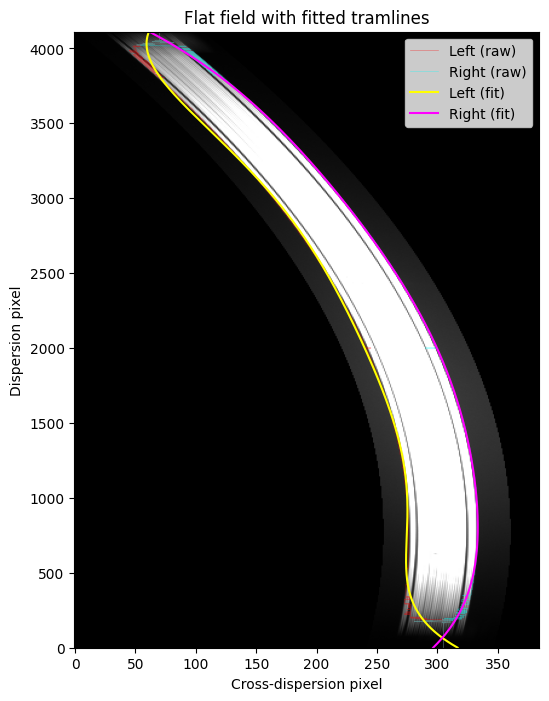

In [164]:


# fit a polynomial of order 6 to the tram lines
poly_order = 6


left_coeffs = np.polyfit(dispersion_pixels, left_tramline, deg=poly_order)
right_coeffs = np.polyfit(dispersion_pixels, right_tramline, deg=poly_order)


left_fit = np.polyval(left_coeffs, dispersion_pixels)
right_fit = np.polyval(right_coeffs, dispersion_pixels)

#plot
plt.figure(figsize=(6, 8))
plt.imshow(flat, aspect='auto', origin='lower', cmap='gray', vmax=5000)
plt.plot(left_tramline, dispersion_pixels, color='red', lw=0.5, alpha=0.4, label='Left (raw)')
plt.plot(right_tramline, dispersion_pixels, color='cyan', lw=0.5, alpha=0.4, label='Right (raw)')
plt.plot(left_fit, dispersion_pixels, color='yellow', lw=1.5, label='Left (fit)')
plt.plot(right_fit, dispersion_pixels, color='magenta', lw=1.5, label='Right (fit)')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.legend()
plt.title('Flat field with fitted tramlines')
plt.savefig("figures/4_1_tramlines_fitted.png", dpi=300)
plt.show()

Each tramline's position waas fitted as a function of dispersion fixel with a 6th order polynomial. This order was chosen by comparing the RNS between detected psotiions and fit from 3-7, and RMS improved up to order 6 and seemed to plateau after. 

The fit performs well through the bulk of the image, but moves away drastically towards the edges. This is expected with higher order polynomials. It would probably be better fit with a piecewise local function.

4.2 Extract Spectrum

In [165]:
#Load moon spectrum

with fits.open('data/moon.fits') as hdul:
    hdul.info()
    moon = hdul[0].data

print("Moon shape:", moon.shape) #make sure it is the same shape as the flat field

Filename: data/moon.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (385, 4112)   float64   
Moon shape: (4112, 385)


C:\Users\aishw\AppData\Local\Temp\ipykernel_9800\2113937430.py:13: RuntimeWarning: invalid value encountered in divide
  ratio = moon_spectrum / flat_spectrum


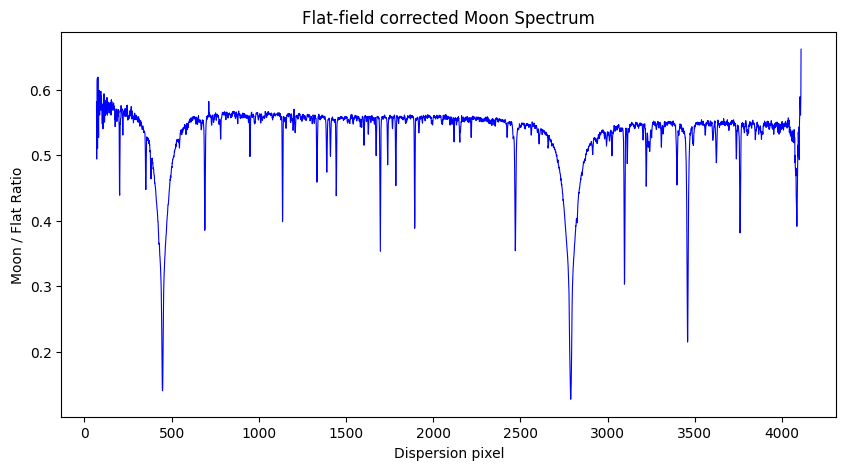

In [166]:
#create arrays as placeholders for spectra
flat_spectrum = np.zeros(n_rows)
moon_spectrum = np.zeros(n_rows)

for row in range(n_rows):
    left = int(round(left_fit[row]))
    right = int(round(right_fit[row]))

    flat_spectrum[row] = np.sum(flat[row, left:right])
    moon_spectrum[row] = np.sum(moon[row, left:right])

#divide moon by flat
ratio = moon_spectrum / flat_spectrum

#plot result

dispersion_pixels = np.arange(n_rows)

plt.figure(figsize=(10, 5))
plt.plot(dispersion_pixels, ratio, color='blue', lw=0.8)
plt.xlabel('Dispersion pixel')
plt.ylabel('Moon / Flat Ratio')
plt.title('Flat-field corrected Moon Spectrum')
plt.savefig("figures/4_2_flat_field_corrected_moon_spectrum.png", dpi=300)
plt.show()

In [167]:
#find pixel locations of dips in the ratio spectrum

#invert so dips become peaks
inverted = 1 - ratio

#find peaks in the inverted spectrum, prominece and width parameters can be adjusted based on the expected features in the spectrum
peaks, properties = find_peaks(inverted, prominence=0.15, width=5)

for p, w in zip(peaks, properties['widths']):
    print(f"Detected dip at pixel {p}, Moon/Flat value: {ratio[p]:.3f}, width: {w:.1f}, depth: {inverted[p]:.3f}")

Detected dip at pixel 447, Moon/Flat value: 0.140, width: 33.9, depth: 0.860
Detected dip at pixel 690, Moon/Flat value: 0.385, width: 5.3, depth: 0.615
Detected dip at pixel 2471, Moon/Flat value: 0.354, width: 6.5, depth: 0.646
Detected dip at pixel 2789, Moon/Flat value: 0.127, width: 50.0, depth: 0.873
Detected dip at pixel 3097, Moon/Flat value: 0.303, width: 5.4, depth: 0.697
Detected dip at pixel 3459, Moon/Flat value: 0.215, width: 8.4, depth: 0.785
Detected dip at pixel 3760, Moon/Flat value: 0.381, width: 5.9, depth: 0.619
Detected dip at pixel 4086, Moon/Flat value: 0.391, width: 9.1, depth: 0.609


Two of the three CaII lines are visible here, with broad and deep absorption features at pixels 447 (likely to be 8662Å), and 2789 (likely to be 8542Å). These likely values are due to the distance between the wavelenghts, and the thrid is slightly unclear. The next deepest value is at pixel 3459, so that is potentially the absorption line at 8498Å, but the ratio is slightly bigger. 
$$ 
(8662 - 8542)/(8542 - 8498) = 2.7
$$//
$$

(2789-447)/(3459-2789) = 3.5

$$

As such, I am treating the dip at 3459 as the 8498Å dip, but there is some uncertainty surrounding this.



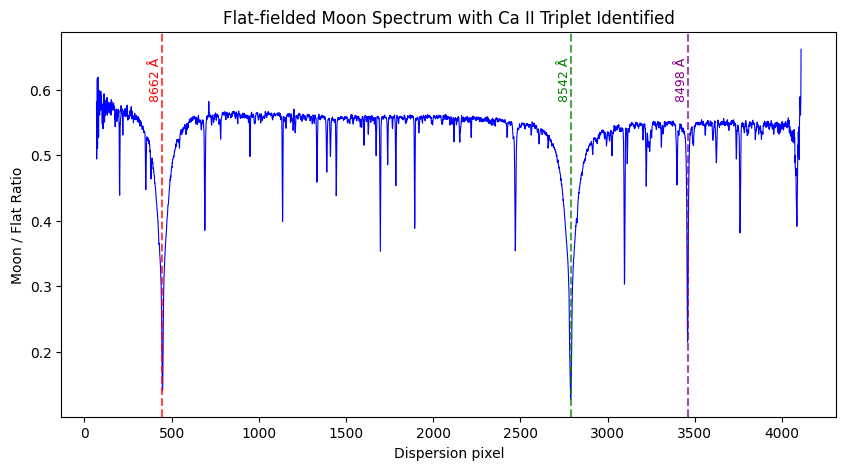

In [168]:
ca_ii_pixels = {8662: 447, 8542: 2789, 8498: 3459}

plt.figure(figsize=(10, 5))
plt.plot(dispersion_pixels, ratio, color='blue', lw=0.8)

colors = ['red', 'green', 'purple']
for (wavelength, pixel), color in zip(ca_ii_pixels.items(), colors):
    plt.axvline(pixel, color=color, linestyle='--', alpha=0.7)
    plt.text(pixel, 0.65, f'{wavelength} Å', rotation=90, color=color,
              ha='right', va='top', fontsize=9)

plt.xlabel('Dispersion pixel')
plt.ylabel('Moon / Flat Ratio')
plt.title('Flat-fielded Moon Spectrum with Ca II Triplet Identified')
plt.savefig("figures/moon_spectrum_ca_ii.png", dpi=300)
plt.show()